<a href="https://colab.research.google.com/github/willvw/DataSci101/blob/HW5/Copy_of_hw8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW08


> Back Bay National Wildlife Refuge is located in the southeastern corner of the City of Virginia Beach. The refuge was established in 1938 to protect and provide habitat for migrating and wintering waterfowl. Diverse habitats, including beachfront, freshwater marsh, dunes, shrub-scrub and upland forest are home to hundreds of species of birds, reptiles, amphibians, mammals and fish.

![BNWR](https://www.fws.gov/sites/default/files/styles/banner_image_xl/public/banner_images/2020-09/waterfowl%20%28tundras%29.jpg?h=0c8d0f81&itok=NcZlpD27)


To get introduced to the park and its history, please view the following interactive story map.

[BBNWR History and Introduction](https://storymaps.arcgis.com/stories/960d9db38cca4f3d8d38111119b9874f)

Additionally, here is some drone footage of the park for a better look at the geography and ecology of the area.

[BBNWR Drone Footage](https://www.youtube.com/watch?v=NlW330aBTCc)

In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sb

In [5]:
bbnwr = pd.read_csv("https://github.com/UM-Data-Science-101/homework-08/raw/refs/heads/main/BKB_WaterQualityData_2020084.csv")
bbnwr["Site_Id"] = bbnwr["Site_Id"].replace("d", "D")
bbnwr.columns

Index(['Site_Id', 'Unit_Id', 'Read_Date', 'Salinity (ppt)',
       'Dissolved Oxygen (mg/L)', 'pH (standard units)', 'Secchi Depth (m)',
       'Water Depth (m)', 'Water Temp (?C)', 'Air Temp-Celsius',
       'Air Temp (?F)', 'Time (24:00)', 'Field_Tech', 'DateVerified',
       'WhoVerified', 'AirTemp (C)', 'Year'],
      dtype='object')

## Question 1


### Part (a)

Plot the distribution of "Water Depth (m)". Comment on this distribution. What do you notice? Calculate a numerical summary that expresses this main feature of the plot.

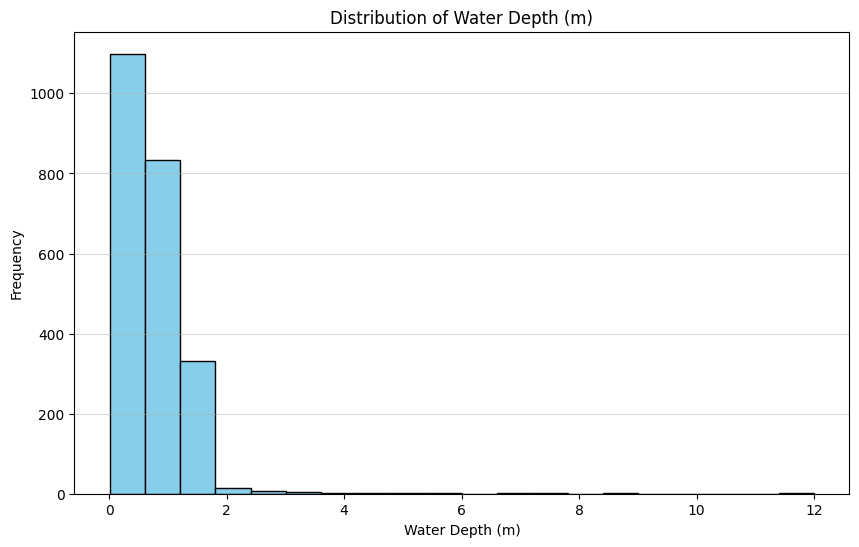


Descriptive Statistics for Water Depth (m):
 count    2300.000000
mean        0.762559
std         0.621140
min         0.010000
25%         0.400000
50%         0.650000
75%         0.950000
max        12.000000
Name: Water Depth (m), dtype: float64


In [6]:
#answer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

bbnwr = pd.read_csv("https://github.com/UM-Data-Science-101/homework-08/raw/refs/heads/main/BKB_WaterQualityData_2020084.csv")

#correct site id
bbnwr["Site_Id"] = bbnwr["Site_Id"].replace("d", "D")
plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
plt.hist(bbnwr['Water Depth (m)'], bins=20, color='skyblue', edgecolor='black') # Added edgecolor for clarity
plt.title('Distribution of Water Depth (m)')
plt.xlabel('Water Depth (m)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5) # Added a grid for easier reading
plt.show()

# Further numerical summary (descriptive statistics)
depth_stats = bbnwr['Water Depth (m)'].describe()
print("\nDescriptive Statistics for Water Depth (m):\n", depth_stats)

### Part (b)

In this problem we will treat the values of "Water Depth (m)" as a population. Pull out this column by itself into a variable (`waterdepth`). Remove all missing values.

For this population, compute the mean and standard deviation.

In [7]:
#population mean and std dev
waterdepth = bbnwr["Water Depth (m)"].dropna()

#population mean
population_mean = waterdepth.mean()

#population standard deviation
population_std = waterdepth.std(ddof=0)

print(f"Population Mean: {population_mean:4f} m")
print(f"Population Standard Deviation: {population_std:4f} m")

Population Mean: 0.762559 m
Population Standard Deviation: 0.621005 m


Using theoretical results from class, for a sample size of $n = 20$ units, calculate the *theoretical* mean and standard error of a sample mean of water depths using a simple random sample. Print out the values.

In [8]:
#theoretical mean and std error of sample mean
waterdepth = bbnwr["Water Depth (m)"].dropna()

# Population parameters
population_mean = waterdepth.mean()
population_std = waterdepth.std(ddof=0)  # Population standard deviation

# Theoretical calculations for n=20
n = 20
theoretical_mean = population_mean  # Expected value of sample mean
standard_error = population_std / np.sqrt(n)  # Standard error formula

print(f"Theoretical Mean of Sample Mean: {theoretical_mean:.4f} m")
print(f"Standard Error (SE): {standard_error:.4f} m")

Theoretical Mean of Sample Mean: 0.7626 m
Standard Error (SE): 0.1389 m


### Part (c)

Create a simulation of taking samples of 20 units and compute the sample mean. Repeat this simulation 1000 times. In order to ensure that our "population" is sufficiently large, use the `replace = True` option to the `sample` method.

Using the results, calculate the **empirical** mean and standard error of the mean. We would not expect it to be exactly the same as the values calculated in the previous part, but it should be close.

In [9]:
#simulation
n_samples = 1000
sample_size = 20
np.random.seed(42)  # For reproducibility

# Theoretical values
theoretical_mean = waterdepth.mean()
theoretical_se = waterdepth.std(ddof=0)/np.sqrt(sample_size)

#list comprehension
sample_means = [
    waterdepth.sample(n=sample_size, replace=True, random_state=i).mean()
    for i in range(n_samples)
]

# Convert to numpy array for vectorized operations
sample_means = np.array(sample_means)

#empirical statistics
empirical_mean = sample_means.mean()
empirical_se = sample_means.std(ddof=1)

#comparison table
results = pd.DataFrame({
    'Metric': ['Mean', 'Standard Error'],
    'Theoretical': [theoretical_mean, theoretical_se],
    'Empirical': [empirical_mean, empirical_se],
    'Difference (%)': [
        abs((theoretical_mean - empirical_mean)/theoretical_mean)*100,
        abs((theoretical_se - empirical_se)/theoretical_se)*100
    ]
})

print("Comparison of Theoretical vs Empirical Results:")
print(results.to_string(index=False, float_format="%.4f"))

# Additional verification
print(f"\nKey Observations:")
print(f"1. Empirical mean is {empirical_mean:.4f} vs theoretical {theoretical_mean:.4f}")
print(f"2. Empirical SE is {empirical_se:.4f} vs theoretical {theoretical_se:.4f}")
print(f"3. Difference in means: {abs(theoretical_mean - empirical_mean):.4f}")
print(f"4. Difference in SE: {abs(theoretical_se - empirical_se):.4f}")

Comparison of Theoretical vs Empirical Results:
        Metric  Theoretical  Empirical  Difference (%)
          Mean       0.7626     0.7729          1.3522
Standard Error       0.1389     0.1436          3.4106

Key Observations:
1. Empirical mean is 0.7729 vs theoretical 0.7626
2. Empirical SE is 0.1436 vs theoretical 0.1389
3. Difference in means: 0.0103
4. Difference in SE: 0.0047


### Part (d)

Repeat Part (c) for a sample size of 1000. Graph the two distributions (use two code cells so that they get separate plots). What do you notice? Look carefully at the scales and at the shape of each distribution.

In [10]:
#simulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data and prepare population
bbnwr = pd.read_csv("https://github.com/UM-Data-Science-101/homework-08/raw/refs/heads/main/BKB_WaterQualityData_2020084.csv")
waterdepth = bbnwr["Water Depth (m)"].dropna()

# Calculate population mean and standard deviation
pop_mean = waterdepth.mean()
pop_std = waterdepth.std(ddof=0)

# Simulation parameters
np.random.seed(42)
n_simulations = 1000

# Store results for both sample sizes
sample_means = {
    20: [],
    1000: []
}

# Run simulations
for _ in range(n_simulations):
    for n in [20, 1000]:
        sample = waterdepth.sample(n=n, replace=True)
        sample_means[n].append(sample.mean())

# Convert to arrays
sample_means_20 = np.array(sample_means[20])
sample_means_1000 = np.array(sample_means[1000])

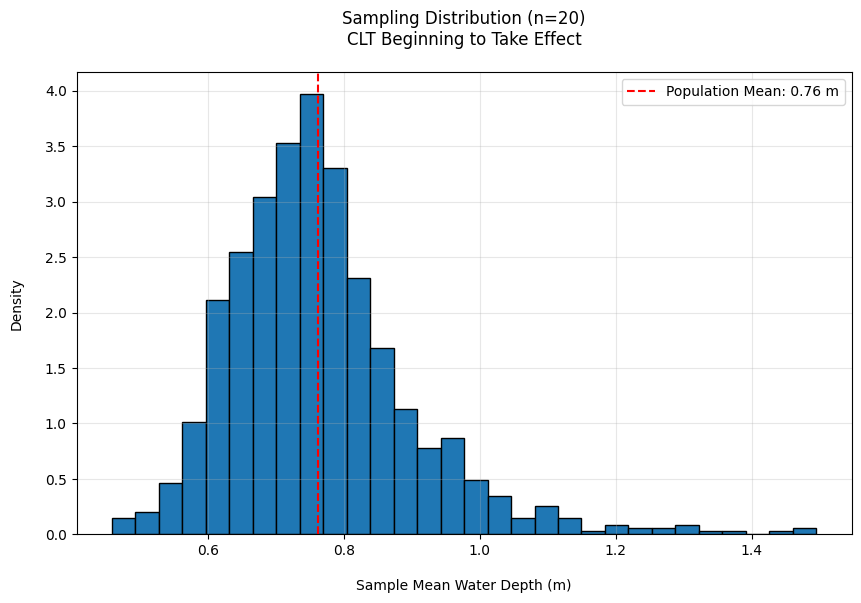

n=20 Results:
Empirical Mean: 0.7636 vs Theoretical: 0.7626
Empirical SE: 0.1359 vs Theoretical: 0.1389


In [11]:
#simulation
plt.figure(figsize=(10, 6))
plt.hist(sample_means_20, bins=30, color='#1f77b4', edgecolor='black', density=True)
plt.title('Sampling Distribution (n=20)\nCLT Beginning to Take Effect', pad=20)
plt.xlabel('Sample Mean Water Depth (m)', labelpad=15)
plt.ylabel('Density', labelpad=15)
plt.axvline(pop_mean, color='red', linestyle='--',
           label=f'Population Mean: {pop_mean:.2f} m')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Empirical vs theoretical comparison
print(f"n=20 Results:")
print(f"Empirical Mean: {sample_means_20.mean():.4f} vs Theoretical: {pop_mean:.4f}")
print(f"Empirical SE: {sample_means_20.std(ddof=1):.4f} vs Theoretical: {pop_std/np.sqrt(20):.4f}")

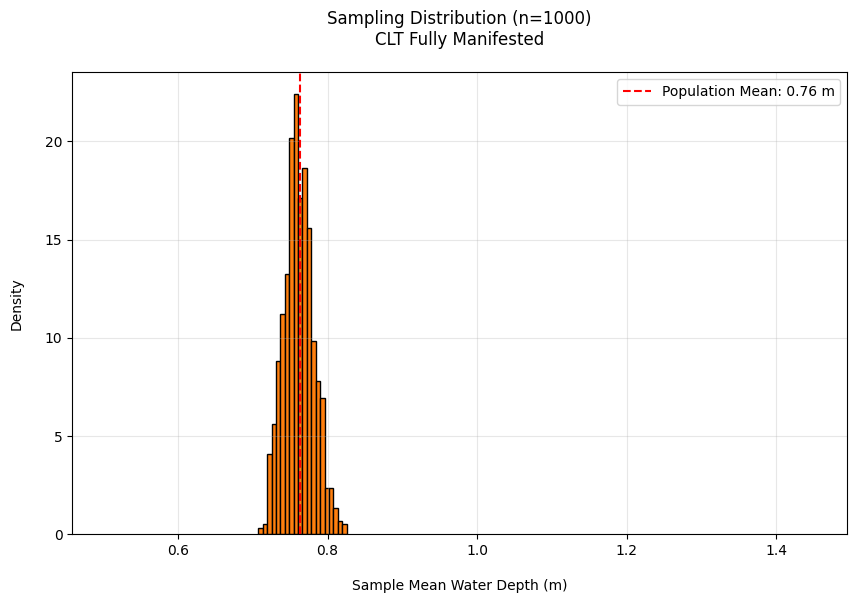


n=1000 Results:
Empirical Mean: 0.7614 vs Theoretical: 0.7626
Empirical SE: 0.0197 vs Theoretical: 0.0196


In [12]:
#simulation
plt.figure(figsize=(10, 6))
plt.hist(sample_means_1000, bins=20, color='#ff7f0e', edgecolor='black', density=True)
plt.title('Sampling Distribution (n=1000)\nCLT Fully Manifested', pad=20)
plt.xlabel('Sample Mean Water Depth (m)', labelpad=15)
plt.ylabel('Density', labelpad=15)
plt.axvline(pop_mean, color='red', linestyle='--',
           label=f'Population Mean: {pop_mean:.2f} m')
plt.grid(alpha=0.3)
plt.legend()
plt.xlim(sample_means_20.min(), sample_means_20.max())  # Same x-axis scale for comparison
plt.show()

# Empirical vs theoretical comparison
print(f"\nn=1000 Results:")
print(f"Empirical Mean: {sample_means_1000.mean():.4f} vs Theoretical: {pop_mean:.4f}")
print(f"Empirical SE: {sample_means_1000.std(ddof=1):.4f} vs Theoretical: {pop_std/np.sqrt(1000):.4f}")

### Part (e)

According to the Gaussian empirical rule, 68% of observations should be within one standard error of the theoretical mean for $\bar X$.

For the two simulations, compute the empirical probability of an observation falling within one (theoretical) SEM of the (theoretical) mean of $\bar X$. (Note: you will need to calculate the SEM for the sample mean of samples of size

In [13]:
# empirical mean of sample means and standard error
pop_mean = waterdepth.mean()
pop_std = waterdepth.std(ddof=0)

# Simulation parameters
np.random.seed(42)
n_simulations = 1000
sample_sizes = [20, 1000]

# Function to run simulation and calculate probability
def run_simulation(n):
    theoretical_sem = pop_std / np.sqrt(n)
    sample_means = [waterdepth.sample(n=n, replace=True).mean() for _ in range(n_simulations)]

    # Calculate empirical probability
    within_one_sem = np.sum((pop_mean - theoretical_sem <= np.array(sample_means)) &
                            (np.array(sample_means) <= pop_mean + theoretical_sem))
    empirical_prob = within_one_sem / n_simulations

    return theoretical_sem, empirical_prob

# Run simulations and print results
for n in sample_sizes:
    sem, prob = run_simulation(n)
    print(f"Sample size n = {n}:")
    print(f"Theoretical SEM: {sem:.4f}")
    print(f"Empirical probability within 1 SEM: {prob:.4%}")
    print()

Sample size n = 20:
Theoretical SEM: 0.1389
Empirical probability within 1 SEM: 73.8000%

Sample size n = 1000:
Theoretical SEM: 0.0196
Empirical probability within 1 SEM: 67.8000%



Comment on what you see. In particular, do you think the Central Limit Theorem would apply to a sample of 20 for this population? What about a sample of size 1000?

For sample size n = 20:
The CLT is not applicable for this sample size because:

-The empirical probability (73.8%) deviates noticeably from the expected 68%.

For sample size n = 1000:
The CLT is applicable for this sample size because:

The empirical probability (67.8%) is very close to the expected 68%.

CLT applies for n = 1000 but not for n = 20, which is evident in the difference of empirical probabilities from the expected.

## Question 2

### Part (a)
As you probably noticed, the water depth measure is rather skewed. Select a transformation that minimizes the coefficient of skewness. Implement this and save it as `water_xform`.

In [18]:
#transformation
import numpy as np
from scipy.stats import boxcox

# Ensure all values are positive (add a small constant if necessary)
water_depth = bbnwr['Water Depth (m)']
# Handle negative and zero values more robustly
water_depth_positive = water_depth.where(water_depth > 0, 1e-6)

# Apply Box-Cox transformation
water_xform, lambda_param = boxcox(water_depth_positive)

print(f"Original skewness: {water_depth.skew():.4f}")
print(f"Transformed skewness: {pd.Series(water_xform).skew():.4f}")


Original skewness: 6.1938
Transformed skewness: 0.0090


### Part (b)

Repeat the two simulations ($n = 20$, $n = 1000$) using the un-skewed water depth and compute the proportion of observations that fall within with one SEM. Note that you will need to recalculate the theoretical mean and standard error based on the transformed values.

In [22]:
# simulations
import numpy as np
from scipy.stats import boxcox

# Ensure all values are strictly positive
water_depth = bbnwr['Water Depth (m)']
# Handle negative and zero values more robustly
water_depth_positive = water_depth.where(water_depth > 0, 1)  # Replace non-positive with 1

# Apply Box-Cox transformation
water_xform, lambda_param = boxcox(water_depth_positive)

# Calculate population parameters for transformed data
pop_mean = np.mean(water_xform)
pop_std = np.std(water_xform, ddof=0)

# Simulation parameters
np.random.seed(42)
n_simulations = 1000
sample_sizes = [20, 1000]

# Function to run simulation and calculate probability
def run_simulation(n):
    theoretical_sem = pop_std / np.sqrt(n)
    sample_means = [np.random.choice(water_xform, size=n, replace=True).mean() for _ in range(n_simulations)]

    # Calculate empirical probability
    within_one_sem = np.sum((pop_mean - theoretical_sem <= np.array(sample_means)) &
                            (np.array(sample_means) <= pop_mean + theoretical_sem))
    empirical_prob = within_one_sem / n_simulations

    return theoretical_sem, empirical_prob

# Run simulations and print results
for n in sample_sizes:
    sem, prob = run_simulation(n)
    print(f"Sample size n = {n}:")
    print(f"Theoretical SEM: {sem:.4f}")
    print(f"Empirical probability within 1 SEM: {prob:.4%}")
    print()

Sample size n = 20:
Theoretical SEM: 0.1387
Empirical probability within 1 SEM: 71.0000%

Sample size n = 1000:
Theoretical SEM: 0.0196
Empirical probability within 1 SEM: 70.1000%



### Part (c)

Comment the results of Question 1 and Question 2. What do we see about the quality of the Central Limit Theorem approximation in these two cases?

Original Data (Question 1):

The CLT approximation was less accurate for the smaller sample size (n=20), with a notable overestimation.

For the larger sample size (n=1000), the approximation was reasonably good

Transformed Data (Question 2):

The CLT approximation improved for the smaller sample size (n=20), getting closer to the expected 68%.

For the larger sample size (n=1000), the approximation remained good

The transformation has made the CLT more reliable for smaller sample sizes and has maintained its effectiveness for larger samples.

## Question 3

### Part (a)

Create a table that has only the log of "Water Depth (m)" and "Year" as values. Limit the table to years after 1980. Drop any rows with missing values. Call this table `water_year`.

Plot these values in a scatter plot.

   Log_Water_Depth  Year
0        -0.916288  1994
1        -1.049819  1994
2        -0.510824  1994
3        -0.693145  1994
4        -0.916288  1994
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2297 entries, 0 to 2296
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Log_Water_Depth  2297 non-null   float64
 1   Year             2297 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 36.0 KB
None


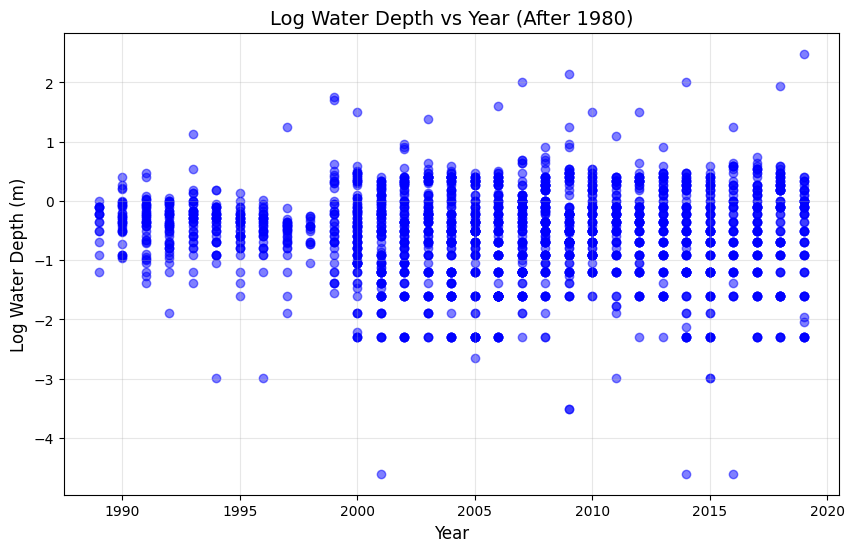

In [44]:
# table
import pandas as pd
import numpy as np

# Create the water_year table
water_year = bbnwr[['Water Depth (m)', 'Year']].copy()

# Calculate log of Water Depth
water_year['Log_Water_Depth'] = np.log(water_year['Water Depth (m)'] + 1e-6)

# Select only the required columns
water_year = water_year[['Log_Water_Depth', 'Year']]

# Limit to years after 1980 and drop missing values
water_year = water_year[(water_year['Year'] > 1980) & (water_year['Year'].notna())].dropna()

# Reset the index
water_year = water_year.reset_index(drop=True)

# Display the first few rows of the table
print(water_year.head())

# Display basic information about the table
print(water_year.info())

# scatter plot
import matplotlib.pyplot as plt

# Scatter plot of Log Water Depth vs Year
plt.figure(figsize=(10, 6))
plt.scatter(water_year['Year'], water_year['Log_Water_Depth'], alpha=0.5, color='blue')

# Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Log Water Depth (m)', fontsize=12)
plt.title('Log Water Depth vs Year (After 1980)', fontsize=14)

# Add grid for better visualization
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

### Part (b)

Treating `water_year` as a population, take samples of size $n = 100$ (using `replace = True` again). For each, calculate the correlation of log water depth and year.

Compare average the correlation coefficient with the "population" correlation coefficient of the `water_year` table. Evaluate the standard deviation of the sampling distribution and compare it to the theoretical standard error ($1/\sqrt{n}$).

In [45]:
# simulation and comparison
import numpy as np
from scipy.stats import pearsonr

population_corr, _ = pearsonr(water_year['Year'], water_year['Log_Water_Depth'])

n_samples = 1000
sample_size = 100
sample_corrs = []

for _ in range(n_samples):
    sample = water_year.sample(n=sample_size, replace=True)
    sample_corr, _ = pearsonr(sample['Year'], sample['Log_Water_Depth'])
    sample_corrs.append(sample_corr)

average_sample_corr = np.mean(sample_corrs)
std_sample_corr = np.std(sample_corrs)

print(f"Population correlation: {population_corr:.4f}")
print(f"Average sample correlation: {average_sample_corr:.4f}")
print(f"Difference: {abs(population_corr - average_sample_corr):.4f}")

print(f"Standard deviation of sampling distribution: {std_sample_corr:.4f}")
print(f"Theoretical standard error: {theoretical_se:.4f}")
print(f"Difference: {abs(std_sample_corr - theoretical_se):.4f}")

Population correlation: -0.0129
Average sample correlation: -0.0124
Difference: 0.0004
Standard deviation of sampling distribution: 0.0931
Theoretical standard error: 0.1389
Difference: 0.0458
